<a href="https://colab.research.google.com/github/AyoubMotei/house-price-prediction/blob/master/Final_House_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install catboost


### 1. IMPORTATION DES BIBLIOTHÈQUES

In [40]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Suppression des avertissements
import warnings
warnings.filterwarnings('ignore')

# Prétraitement
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Modèles
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error

# Modèles avancés
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimisation
from scipy.optimize import minimize

# Configuration d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Les bibliothèques sont chargées.")

Les bibliothèques sont chargées.


### 2. CHARGEMENT DES DONNÉES

In [41]:
# Chargement des fichiers
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Sauvegarde des données originales pour les visualisations
train_raw = train.copy()
test_raw = test.copy()


print("ANALYSE DES DONNÉES \n")


print(f"\n Dimensions des données :")
print(f"Train : {train.shape[0]} maisons, {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]} maisons, {test.shape[1]} colonnes")

print(f"\n Aperçu des données d'entraînement :")
print(train.head())

print(f"\n Types de colonnes :")
print(train.dtypes.value_counts())

print(f"\n Valeurs manquantes (top 10) :")
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.head(10))

ANALYSE DES DONNÉES 


 Dimensions des données :
Train : 1022 maisons, 81 colonnes
Test  : 438 maisons, 80 colonnes

 Aperçu des données d'entraînement :
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   136          20       RL         80.0    10400   Pave   NaN      Reg   
1  1453         180       RM         35.0     3675   Pave   NaN      Reg   
2   763          60       FV         72.0     8640   Pave   NaN      Reg   
3   933          20       RL         84.0    11670   Pave   NaN      IR1   
4   436          60       RL         43.0    10667   Pave   NaN      IR2   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl       NWAmes       Norm   
1         Lvl    AllPub    Inside       Gtl      Edwards       Norm   
2         Lvl    AllPub    Inside       Gtl      Somerst       Norm   
3         Lvl    AllPub    Corner       Gtl      Somerst       RRNn   
4         Lvl    AllPub   CulDSac 

### 3. ANALYSE EXPLORATOIRE DES DONNÉES

#### 3.1  Distribution de la cible (SalePrice)

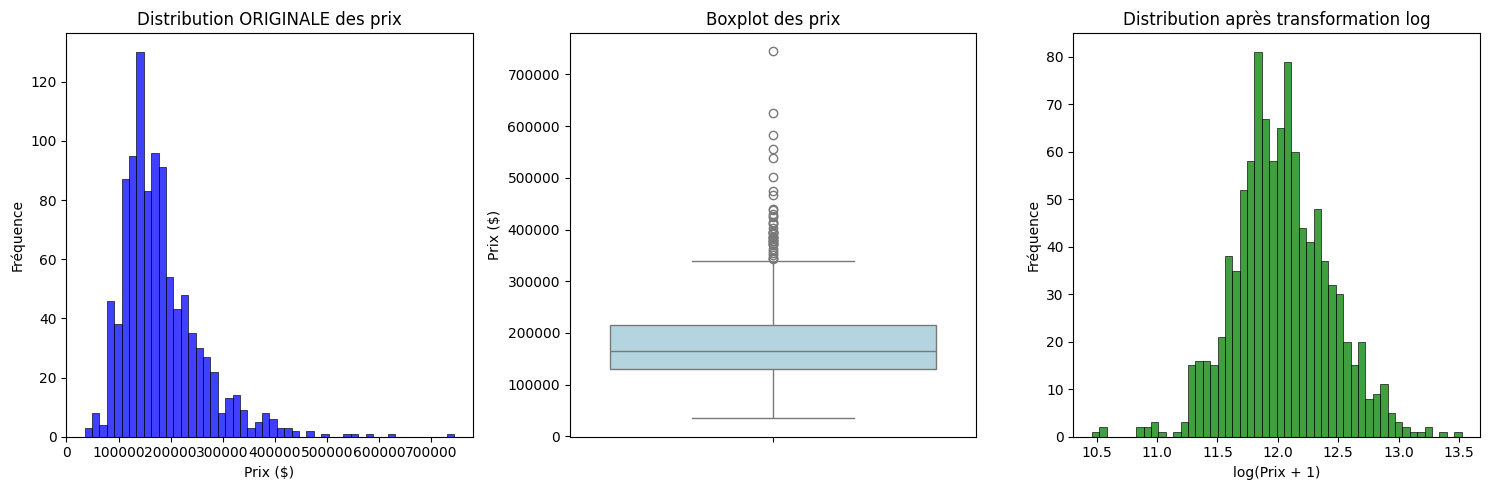


 Statistiques des prix :
 Minimum : 34900 $
 Maximum : 745000 $
 Moyenne : 181313 $
 Médiane : 165000 $


In [44]:
plt.figure(figsize=(15, 5))

# 1. Histogramme des prix originaux
plt.subplot(1, 3, 1)
sns.histplot(train['SalePrice'], bins=50, color='blue')
plt.title('Distribution ORIGINALE des prix')
plt.xlabel('Prix ($)')
plt.ylabel('Fréquence')

# 2. Boxplot des prix
plt.subplot(1, 3, 2)
sns.boxplot(y=train['SalePrice'], color='lightblue')
plt.title('Boxplot des prix')
plt.ylabel('Prix ($)')

# 3. Histogramme après log (création temporaire)
plt.subplot(1, 3, 3)
sale_price_log = np.log1p(train['SalePrice'])
sns.histplot(sale_price_log, bins=50, color='green')
plt.title('Distribution après transformation log')
plt.xlabel('log(Prix + 1)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

print("\n Statistiques des prix :")
print(f" Minimum : {train['SalePrice'].min():.0f} $")
print(f" Maximum : {train['SalePrice'].max():.0f} $")
print(f" Moyenne : {train['SalePrice'].mean():.0f} $")
print(f" Médiane : {train['SalePrice'].median():.0f} $")



 Après transformation logarithmique, la distribution est plus symétrique.

Le logarithme transforme les données pour :
1. Rendre la distribution plus symétrique (moins asymétrique)
2. Réduire l'impact des valeurs extrêmes (outliers)
3. Stabiliser la variance
4. Permettre au modèle linéaire de mieux capturer les relations non linéaires

#### 3.2 CORRÉLATIONS AVEC LE PRIX

TOP 15 DES CORRÉLATIONS AVEC LE PRIX 

1. QualTotalSF: 0.825
2. QualArea: 0.808
3. OverallQual: 0.785
4. QualityScore: 0.780
5. TotalSF: 0.756
6. TotalSF_Log: 0.752
7. Neighborhood_Enc: 0.717
8. GrLivArea: 0.689
9. GrLivArea_Log: 0.687
10. ExterQual_num: 0.659
11. KitchenQual_num: 0.656
12. GarageCars: 0.643
13. GarageArea: 0.622
14. TotalBaths: 0.617
15. TotalBsmtSF: 0.590


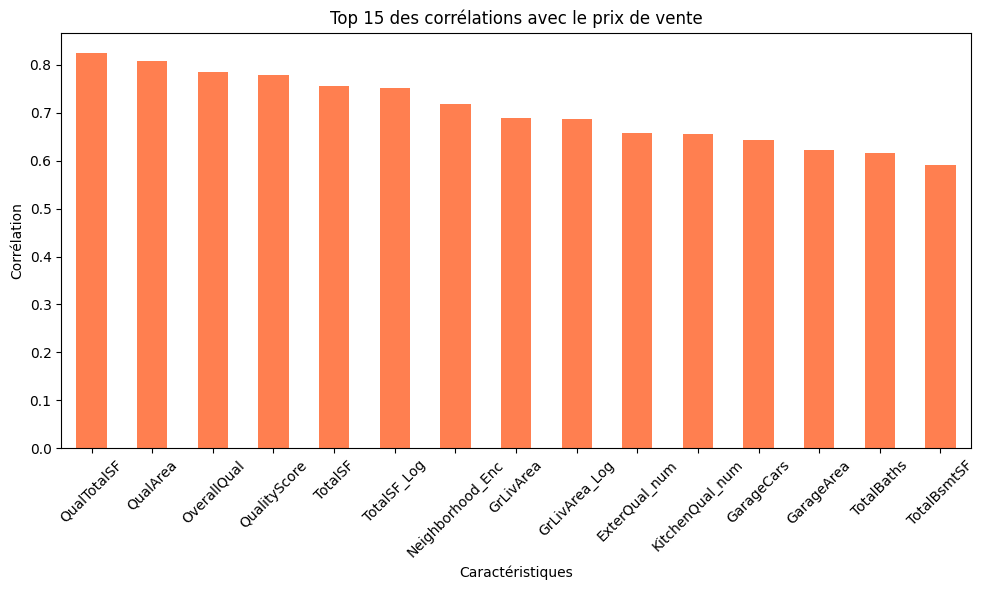

In [77]:
# Sélection des colonnes numériques
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('SalePrice')
if 'SalePrice_log' in numeric_cols:
    numeric_cols.remove('SalePrice_log')

# Calcul des corrélations
correlations = train[numeric_cols].corrwith(train['SalePrice']).sort_values(ascending=False)

print("TOP 15 DES CORRÉLATIONS AVEC LE PRIX \n")

for i, (col, corr) in enumerate(correlations.head(15).items(), 1):
    print(f"{i}. {col}: {corr:.3f}")

# Visualisation
plt.figure(figsize=(10, 6))
correlations.head(15).plot(kind='bar', color='coral')
plt.title('Top 15 des corrélations avec le prix de vente')
plt.xlabel('Caractéristiques')
plt.ylabel('Corrélation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observations :
    'OverallQual' (qualité globale) est la plus corrélée
    'GrLivArea' (surface habitable) est très importante
    'TotalBsmtSF' (surface sous-sol) est également significative

#### 3.3 Creation de catégories de prix

In [45]:
# 1.Créer la colonne log des prix
train['SalePrice_log'] = np.log1p(train['SalePrice'])

# 2.Créer la catégorie de prix
def price_category(price):
    if price < 100000:
        return 'Petite (<100k)'
    elif price < 200000:
        return 'Moyenne (100k-200k)'
    elif price < 300000:
        return 'Grande (200k-300k)'
    else:
        return 'Très grande (>300k)'

train['PriceCategory'] = train['SalePrice'].apply(price_category)

# 3. Vérifier la création des colonnes
print("\n Colonnes créées :")
print(f"SalePrice_log : {train['SalePrice_log'].dtype}")
print(f"PriceCategory : {train['PriceCategory'].dtype}")

# Statistiques par catégorie
print("\n Répartition des maisons par catégorie de prix :")
price_counts = train['PriceCategory'].value_counts()
for cat, count in price_counts.items():
    pct = 100 * count / len(train)
    print(f"   {cat}: {count} maisons ({pct:.1f}%)")


 Colonnes créées :
SalePrice_log : float64
PriceCategory : object

 Répartition des maisons par catégorie de prix :
   Moyenne (100k-200k): 633 maisons (61.9%)
   Grande (200k-300k): 232 maisons (22.7%)
   Petite (<100k): 79 maisons (7.7%)
   Très grande (>300k): 78 maisons (7.6%)


On ajoute `SalePrice_log` et `PriceCategory` (petite, moyenne, grande, très grande) pour faciliter l’analyse.

#### 3.4 VISUALISATION DE L'EFFET DU LOGARITHME


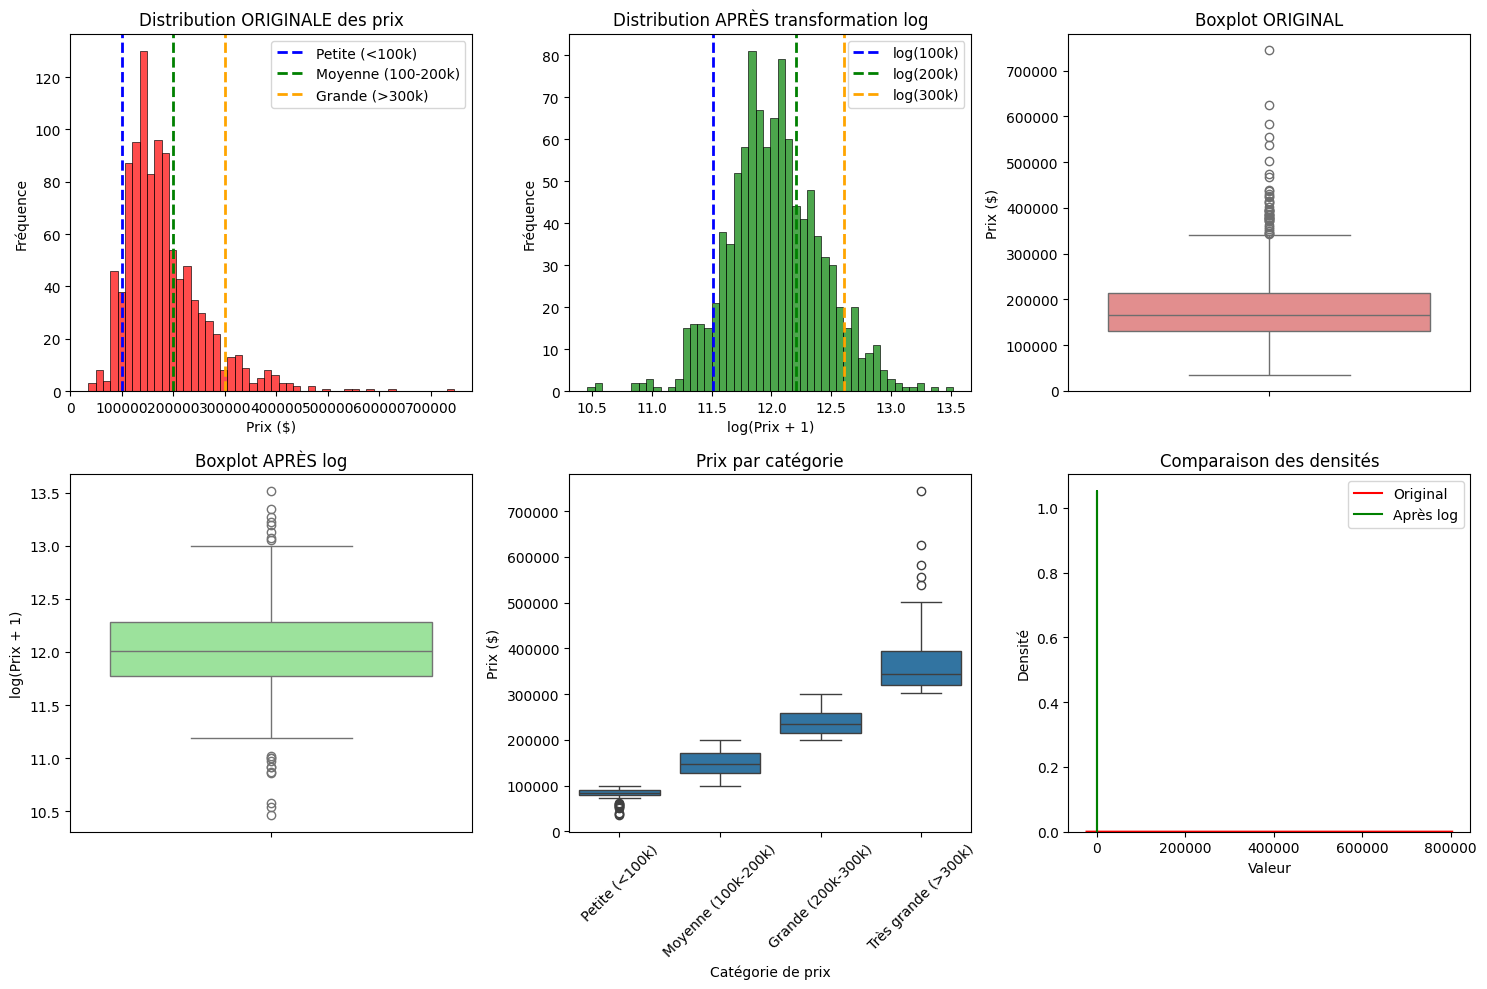

In [16]:
# Assurer que les colonnes existent
if 'SalePrice_log' not in train.columns:
    train['SalePrice_log'] = np.log1p(train['SalePrice'])
if 'PriceCategory' not in train.columns:
    def price_category(price):
        if price < 100000:
            return 'Petite (<100k)'
        elif price < 200000:
            return 'Moyenne (100k-200k)'
        elif price < 300000:
            return 'Grande (200k-300k)'
        else:
            return 'Très grande (>300k)'
    train['PriceCategory'] = train['SalePrice'].apply(price_category)

plt.figure(figsize=(15, 10))

# 1. Distribution originale
plt.subplot(2, 3, 1)
sns.histplot(train['SalePrice'], bins=50, color='red', alpha=0.7)
plt.title('Distribution ORIGINALE des prix')
plt.xlabel('Prix ($)')
plt.ylabel('Fréquence')
plt.axvline(x=100000, color='blue', linestyle='--', linewidth=2, label='Petite (<100k)')
plt.axvline(x=200000, color='green', linestyle='--', linewidth=2, label='Moyenne (100-200k)')
plt.axvline(x=300000, color='orange', linestyle='--', linewidth=2, label='Grande (>300k)')
plt.legend()

# 2. Distribution après logarithme
plt.subplot(2, 3, 2)
sns.histplot(train['SalePrice_log'], bins=50, color='green', alpha=0.7)
plt.title('Distribution APRÈS transformation log')
plt.xlabel('log(Prix + 1)')
plt.ylabel('Fréquence')
plt.axvline(x=np.log1p(100000), color='blue', linestyle='--', linewidth=2, label='log(100k)')
plt.axvline(x=np.log1p(200000), color='green', linestyle='--', linewidth=2, label='log(200k)')
plt.axvline(x=np.log1p(300000), color='orange', linestyle='--', linewidth=2, label='log(300k)')
plt.legend()

# 3. Boxplot original
plt.subplot(2, 3, 3)
sns.boxplot(y=train['SalePrice'], color='lightcoral')
plt.title('Boxplot ORIGINAL')
plt.ylabel('Prix ($)')

# 4. Boxplot après log
plt.subplot(2, 3, 4)
sns.boxplot(y=train['SalePrice_log'], color='lightgreen')
plt.title('Boxplot APRÈS log')
plt.ylabel('log(Prix + 1)')

# 5. Prix par catégorie
plt.subplot(2, 3, 5)
sns.boxplot(x='PriceCategory', y='SalePrice', data=train, order=['Petite (<100k)', 'Moyenne (100k-200k)', 'Grande (200k-300k)', 'Très grande (>300k)'])
plt.title('Prix par catégorie')
plt.xlabel('Catégorie de prix')
plt.ylabel('Prix ($)')
plt.xticks(rotation=45)

# 6. Densité comparée
plt.subplot(2, 3, 6)
sns.kdeplot(train['SalePrice'], label='Original', color='red')
sns.kdeplot(train['SalePrice_log'], label='Après log', color='green')
plt.title('Comparaison des densités')
plt.xlabel('Valeur')
plt.ylabel('Densité')
plt.legend()

plt.tight_layout()
plt.show()


 Observations :
  - Distribution originale : asymétrique à droite (longue traîne)
  - Après log : distribution symétrique (forme de cloche)
  - Les boxplots montrent une réduction des outliers après log
  - La transformation log est ESSENTIELLE pour ce problème !

# 3.4 Explication Mathématique du logarithme


In [47]:
# Création d'un exemple
prices_real = [50000, 100000, 200000, 300000, 500000]

print("\n Exemple : Erreur de 10 000€ sur différentes maisons")
print(f"{'Prix réel':<15} {'Erreur':<10} {'Erreur relative':<20} {'Erreur log':<15}")

for price in prices_real:
    # Erreur relative classique
    rel_error = 10000 / price

    # Erreur en log (ce que mesure le RMSLE)
    log_error = np.log1p(price + 10000) - np.log1p(price)

    print(f"{price:<15.0f} {10000:<10} {rel_error*100:<20.2f}% {log_error:<15.6f}")



 Exemple : Erreur de 10 000€ sur différentes maisons
Prix réel       Erreur     Erreur relative      Erreur log     
50000           10000      20.00               % 0.182318       
100000          10000      10.00               % 0.095309       
200000          10000      5.00                % 0.048790       
300000          10000      3.33                % 0.032790       
500000          10000      2.00                % 0.019803       


INTERPRÉTATION :

1. Erreur relative classique (RMSE) :
   - 10 000€ sur une maison à 50 000€ = 20% d'erreur → TRÈS GRAVE
   - 10 000€ sur une maison à 500 000€ = 2% d'erreur → PEU GRAVE
   → Le RMSE pénalise PLUS les petites maisons

2. Erreur logarithmique (RMSLE) :
   - log(60 000) - log(50 000) ≈ 0.182
   - log(510 000) - log(500 000) ≈ 0.020
   → L'erreur en log est PROPORTIONNELLE au prix
   
CONCLUSION : Le RMSLE est plus adapté car il :
   - Pénalise de la même façon les petites et grandes maisons en proportion
   - Est symétrique (sous-estimation = surestimation)
   - Correspond à une erreur relative


### 4. FEATURE ENGINEERING (CRÉATION DE NOUVELLES CARACTÉRISTIQUES)

In [48]:
print("CRÉATION DE NOUVELLES CARACTÉRISTIQUES")

def create_features(df, is_train=True):

    # 4.1 Surface totale
    df['TotalSF'] = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'] + df['2ndFlrSF']

    # 4.2 Âges
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

    # 4.3 Salles de bain totales
    df['TotalBaths'] = (df['FullBath'] + 0.5*df['HalfBath'] +
                        df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']).fillna(0)

    # 4.4 Interactions (Qualité × Surface)
    df['QualArea'] = df['OverallQual'] * df['GrLivArea']
    df['QualTotalSF'] = df['OverallQual'] * df['TotalSF']

    # 4.5 Transformations logarithmiques
    df['GrLivArea_Log'] = np.log1p(df['GrLivArea'])
    df['TotalSF_Log'] = np.log1p(df['TotalSF'])
    df['LotArea_Log'] = np.log1p(df['LotArea'])

    # 4.6 Ratios
    df['GarageRatio'] = df['GarageArea'].fillna(0) / (df['GrLivArea'] + 1)
    df['BathsPerRoom'] = df['TotalBaths'] / (df['TotRmsAbvGrd'] + 1)

    # 4.7 Variables binaires
    df['HasGarage'] = (df['GarageArea'].fillna(0) > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasFinishedBsmt'] = (df['BsmtFinSF1'].fillna(0) + df['BsmtFinSF2'].fillna(0)) > 0
    df['HasCentralAir'] = (df['CentralAir'] == 'Y').astype(int)

    # 4.8 Qualité numérique
    qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
    for col in ['ExterQual', 'ExterCond', 'KitchenQual', 'HeatingQC']:
        df[f'{col}_num'] = df[col].map(qual_map).fillna(3)

    # 4.9 Score de qualité global
    df['QualityScore'] = (df['OverallQual'] * df['ExterQual_num'] *
                          df['KitchenQual_num'] * df['HeatingQC_num'])

    # 4.10 Target encoding (uniquement pour l'entraînement)
    if is_train:
        for col in ['Neighborhood', 'MSZoning', 'SaleType']:
            means = df.groupby(col)['SalePrice'].mean()
            df[f'{col}_Enc'] = df[col].map(means)
            df[f'{col}_Enc'] = np.log1p(df[f'{col}_Enc'])

    return df

# Application du feature engineering
train_fe = create_features(train, is_train=True)
test_fe = create_features(test, is_train=False)

print(f"\n Nouvelles colonnes créées !")
print(f"   Train : {train_fe.shape[1]} colonnes")
print(f"   Test  : {test_fe.shape[1]} colonnes")

# Afficher les nouvelles colonnes
new_cols = ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBaths', 'QualArea',
            'GrLivArea_Log', 'GarageRatio', 'HasGarage', 'QualityScore']
print(f"\n Nouvelles colonnes ajoutées :")
for col in new_cols:
    print(f"   - {col}")

CRÉATION DE NOUVELLES CARACTÉRISTIQUES

 Nouvelles colonnes créées !
   Train : 106 colonnes
   Test  : 100 colonnes

 Nouvelles colonnes ajoutées :
   - TotalSF
   - HouseAge
   - RemodAge
   - TotalBaths
   - QualArea
   - GrLivArea_Log
   - GarageRatio
   - HasGarage
   - QualityScore


#### 4.1 TARGET ENCODING POUR LE TEST

In [49]:
# Calcul des moyennes sur les données d'entraînement
neigh_means = train_fe.groupby('Neighborhood')['SalePrice'].mean()
zoning_means = train_fe.groupby('MSZoning')['SalePrice'].mean()
saletype_means = train_fe.groupby('SaleType')['SalePrice'].mean()

# Application au test
test_fe['Neighborhood_Enc'] = test_fe['Neighborhood'].map(neigh_means).fillna(train_fe['SalePrice'].mean())
test_fe['MSZoning_Enc'] = test_fe['MSZoning'].map(zoning_means).fillna(train_fe['SalePrice'].mean())
test_fe['SaleType_Enc'] = test_fe['SaleType'].map(saletype_means).fillna(train_fe['SalePrice'].mean())

# Transformation logarithmique
test_fe['Neighborhood_Enc'] = np.log1p(test_fe['Neighborhood_Enc'])
test_fe['MSZoning_Enc'] = np.log1p(test_fe['MSZoning_Enc'])
test_fe['SaleType_Enc'] = np.log1p(test_fe['SaleType_Enc'])

print("Target encoding appliqué au test")

Target encoding appliqué au test


pour les colonnes `Neighborhood`, `MSZoning`, `SaleType`, on remplace les catégories par la moyenne du prix dans le train. On applique ensuite un logarithme. Cela capte l’effet de ces variables de manière plus puissante qu’un one-hot encoding. Pour le test, on utilise les moyennes calculées sur le train.

#### 4.2 VISUALISATION DES NOUVELLES FEATURES

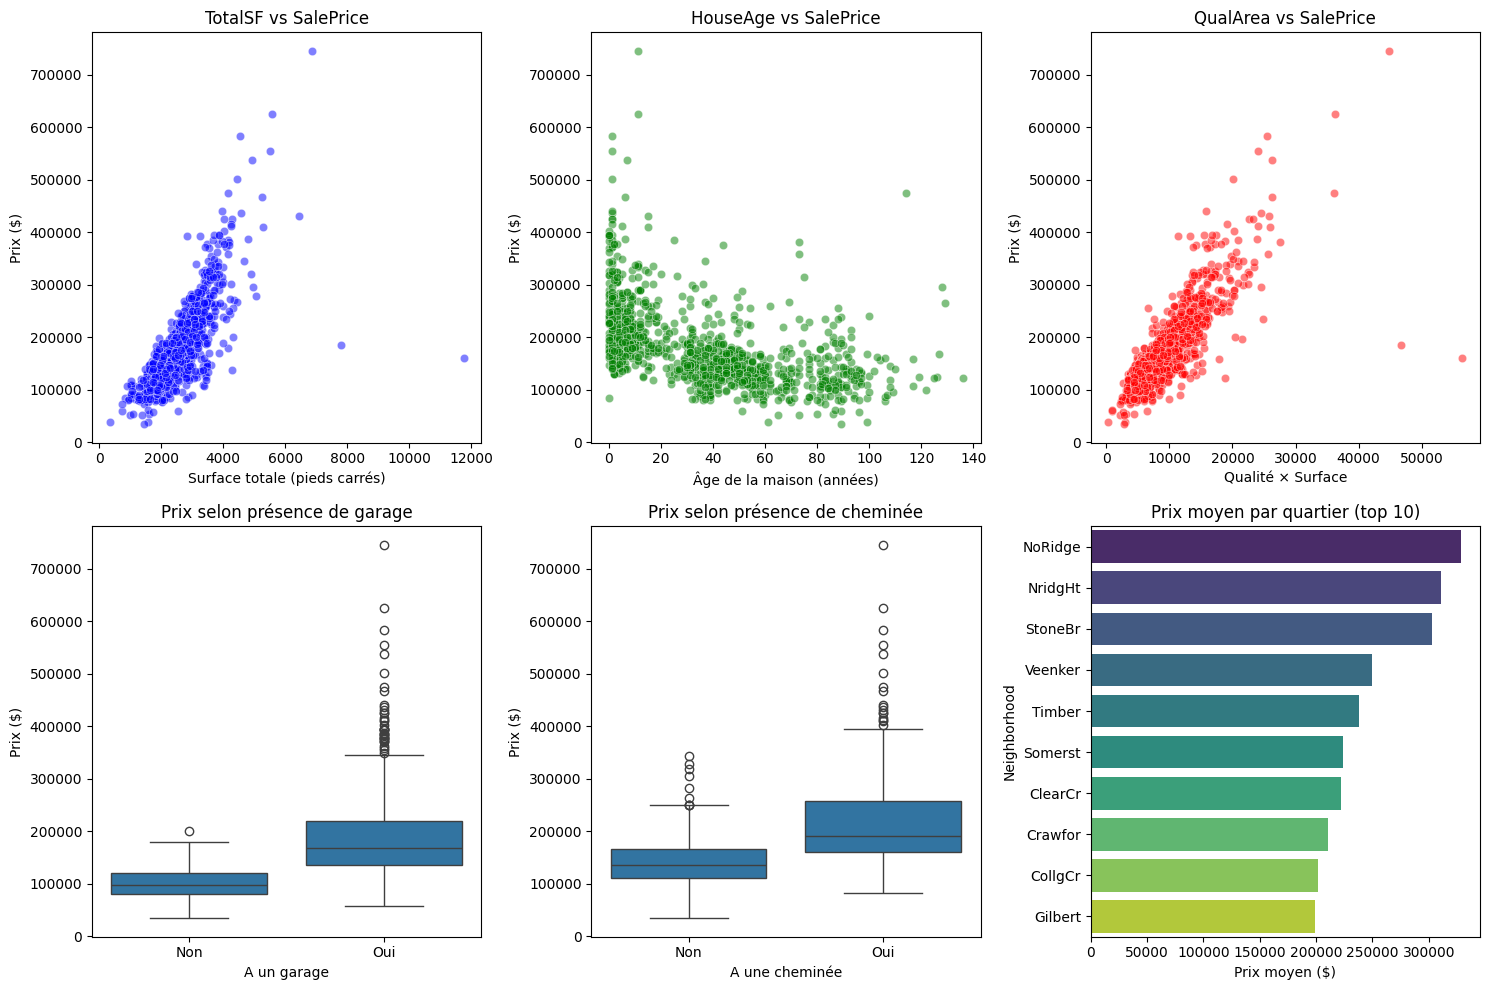

In [50]:
plt.figure(figsize=(15, 10))

# 1. Relation Surface totale vs Prix
plt.subplot(2, 3, 1)
sns.scatterplot(x=train_fe['TotalSF'], y=train_fe['SalePrice'], alpha=0.5, color='blue')
plt.title('TotalSF vs SalePrice')
plt.xlabel('Surface totale (pieds carrés)')
plt.ylabel('Prix ($)')

# 2. Relation Âge vs Prix
plt.subplot(2, 3, 2)
sns.scatterplot(x=train_fe['HouseAge'], y=train_fe['SalePrice'], alpha=0.5, color='green')
plt.title('HouseAge vs SalePrice')
plt.xlabel('Âge de la maison (années)')
plt.ylabel('Prix ($)')

# 3. Relation Qualité × Surface vs Prix
plt.subplot(2, 3, 3)
sns.scatterplot(x=train_fe['QualArea'], y=train_fe['SalePrice'], alpha=0.5, color='red')
plt.title('QualArea vs SalePrice')
plt.xlabel('Qualité × Surface')
plt.ylabel('Prix ($)')

# 4. Boxplot par présence de garage
plt.subplot(2, 3, 4)
sns.boxplot(x=train_fe['HasGarage'], y=train_fe['SalePrice'])
plt.title('Prix selon présence de garage')
plt.xlabel('A un garage')
plt.ylabel('Prix ($)')
plt.xticks([0, 1], ['Non', 'Oui'])

# 5. Boxplot par présence de cheminée
plt.subplot(2, 3, 5)
sns.boxplot(x=train_fe['HasFireplace'], y=train_fe['SalePrice'])
plt.title('Prix selon présence de cheminée')
plt.xlabel('A une cheminée')
plt.ylabel('Prix ($)')
plt.xticks([0, 1], ['Non', 'Oui'])

# 6. Prix par quartier (top 10)
plt.subplot(2, 3, 6)
neigh_prices = train_fe.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=neigh_prices.values, y=neigh_prices.index, palette='viridis')
plt.title('Prix moyen par quartier (top 10)')
plt.xlabel('Prix moyen ($)')
plt.tight_layout()
plt.show()

 Observations des visualisations :
 1. La surface totale est fortement corrélée au prix
 2. Les maisons neuves sont généralement plus chères
 3. La présence d'un garage ou d'une cheminée augmente le prix
 4. Le quartier a un impact majeur sur le prix

### 5. SUPPRESSION DES OUTLIERS (VALEURS ABERRANTES)

In [51]:
print("SUPPRESSION DES OUTLIERS")

original_size = len(train_fe)

# Suppression des maisons avec surface inhabitable trop grande
train_fe = train_fe[train_fe['GrLivArea'] <= 4500]

# Suppression des maisons avec prix trop élevés
train_fe = train_fe[train_fe['SalePrice'] <= 550000]

# Suppression des maisons avec terrain trop grand
train_fe = train_fe[train_fe['LotArea'] <= 100000]

print(f"\n Maisons supprimées : {original_size - len(train_fe)}")
print(f"   Train après nettoyage : {len(train_fe)} maisons")

SUPPRESSION DES OUTLIERS

 Maisons supprimées : 10
   Train après nettoyage : 1012 maisons


Ces points sont rares et peuvent tirer le modèle vers des extrêmes, nuisant à la généralisation. On perd seulement 10 maisons (sur 1022), ce qui est acceptable.

#### 5.1 VISUALISATION DES OUTLIERS SUPPRIMÉS

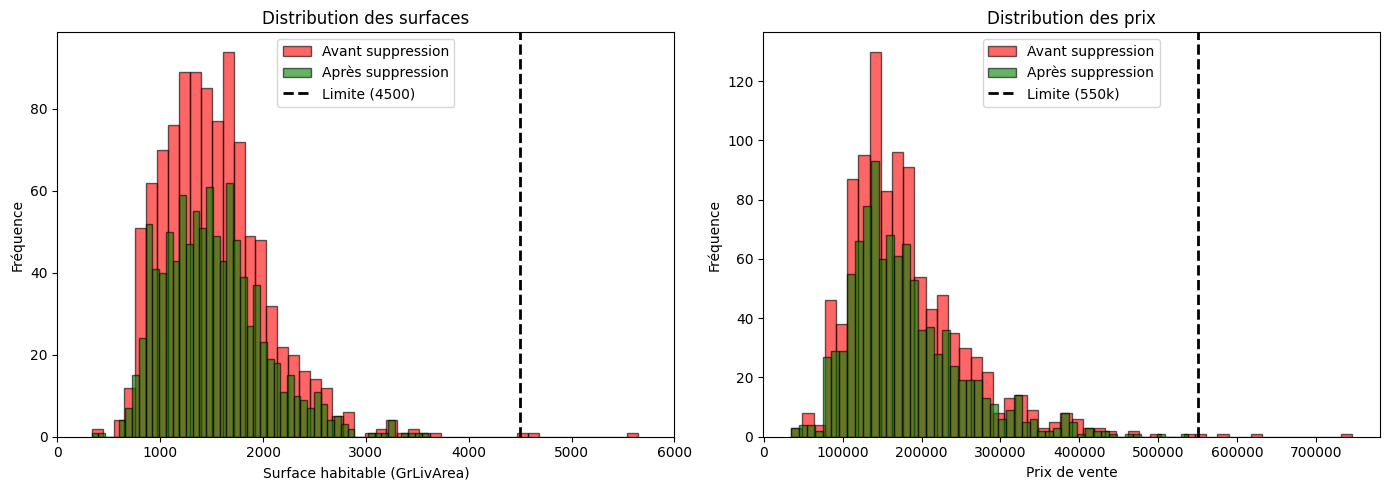

In [52]:
# 5.1 VISUALISATION DES OUTLIERS SUPPRIMÉS

plt.figure(figsize=(14, 5))

# Graphique 1 : Surfaces
plt.subplot(1, 2, 1)
plt.hist(train_raw['GrLivArea'], bins=50, color='red', alpha=0.6, label='Avant suppression', edgecolor='black')
plt.hist(train_fe['GrLivArea'], bins=50, color='green', alpha=0.6, label='Après suppression', edgecolor='black')
plt.axvline(x=4500, color='black', linestyle='--', linewidth=2, label='Limite (4500)')
plt.title('Distribution des surfaces')
plt.xlabel('Surface habitable (GrLivArea)')
plt.ylabel('Fréquence')
plt.legend()
plt.xlim(0, 6000)

# Graphique 2 : Prix
plt.subplot(1, 2, 2)
plt.hist(train_raw['SalePrice'], bins=50, color='red', alpha=0.6, label='Avant suppression', edgecolor='black')
plt.hist(train_fe['SalePrice'], bins=50, color='green', alpha=0.6, label='Après suppression', edgecolor='black')
plt.axvline(x=550000, color='black', linestyle='--', linewidth=2, label='Limite (550k)')
plt.title('Distribution des prix')
plt.xlabel('Prix de vente')
plt.ylabel('Fréquence')
plt.legend()

plt.tight_layout()
plt.show()



Les outliers ont été supprimés pour améliorer la robustesse du modèle.

### 6. PRÉPARATION DES DONNÉES (PIPELINE)

In [53]:
print("PRÉPARATION DES DONNÉES")

# Séparation des features et de la cible
X_train = train_fe.drop('SalePrice', axis=1)
y_train = np.log1p(train_fe['SalePrice'])
X_test = test_fe.copy()

# Sauvegarde des IDs pour la soumission
test_ids = X_test['Id'].copy()

# Identification des colonnes numériques et catégorielles
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\n Types de colonnes :")
print(f"   Numériques : {len(numeric_cols)}")
print(f"   Catégorielles : {len(categorical_cols)}")

PRÉPARATION DES DONNÉES

 Types de colonnes :
   Numériques : 60
   Catégorielles : 44


#### 6.1 CRÉATION DES PIPELINES

In [72]:
# Pipeline pour les colonnes numériques
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les colonnes catégorielles
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinaison des deux pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])



Pipelines créés :
  - Numeric : Imputation (médiane) → Standardisation
  - Categorical : Imputation ('Missing') → One-hot encoding"

#### 6.2 TRANSFORMATION DES DONNÉES

In [73]:
print("\n RECONSTRUCTION COMPLÈTE DES DONNÉES...")

# 1. Prendre les DataFrames originaux
X_train = train_fe.drop('SalePrice', axis=1)
y_train = np.log1p(train_fe['SalePrice'])
X_test = test_fe.copy()

# 2. Supprimer les colonnes problématiques (sans erreur)
cols_to_remove = ['PriceCategory', 'SalePrice_log', 'Id']
for col in cols_to_remove:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
    if col in X_test.columns:
        X_test = X_test.drop(columns=[col])

# 3. Identifier les colonnes numériques et catégorielles
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"   Numériques : {len(numeric_cols)}")
print(f"   Catégorielles : {len(categorical_cols)}")

# 4. Pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# 5. Transformation
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"\n Shape entraînement : {X_train_proc.shape}")
print(f" Shape test : {X_test_proc.shape}")


 RECONSTRUCTION COMPLÈTE DES DONNÉES...
   Numériques : 58
   Catégorielles : 43

 Shape entraînement : (1012, 319)
 Shape test : (438, 319)


### 7. Entrainement des modéles et VALIDATION CROISÉE

In [55]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

print("ENTRAÎNEMENT DES MODÈLES")
print("\n Validation croisée 10-fold")

ENTRAÎNEMENT DES MODÈLES

 Validation croisée 10-fold


#### 7.1 Modéles Testés :

##### 7.1.1 MODÈLE LASSO


In [56]:
print("\n Lasso (Régression avec sélection de features)")
lasso = Lasso(alpha=0.0005, max_iter=10000, random_state=42)
lasso.fit(X_train_proc, y_train)
lasso_pred_train = lasso.predict(X_train_proc)
lasso_score = np.sqrt(mean_squared_error(y_train, lasso_pred_train))
print(f" Score validation : {lasso_score:.4f}")

# Affichage des coefficients non nuls
non_zero_coef = np.sum(lasso.coef_ != 0)
total_coef = len(lasso.coef_)
print(f" Features sélectionnées : {non_zero_coef}/{total_coef} ({100*non_zero_coef/total_coef:.1f}%)")


 Lasso (Régression avec sélection de features)
 Score validation : 0.0930
 Features sélectionnées : 111/319 (34.8%)


 -`alpha=0.0005 :` Force de la régularisation  (le plus important). <br>
  Plus alpha est grand → plus le modèle supprime des variables (met des coefficients à 0). <br>
 -`max_iter=10000 :` Nombre maximum d’itérations pour que l’algorithme converge.<br>
-`random_state=42 :` Graine aléatoire pour rendre les résultats reproductibles.

##### 7.1.2 MODÈLE RIDGE

In [57]:
print("\n Ridge (Régression avec stabilisation)...")
ridge = Ridge(alpha=0.3)
ridge.fit(X_train_proc, y_train)
ridge_score = np.sqrt(mean_squared_error(y_train, ridge.predict(X_train_proc)))
print(f"Score validation : {ridge_score:.4f}")


 Ridge (Régression avec stabilisation)...
Score validation : 0.0814


##### 7.1.3  MODÈLE ELASTICNET

In [29]:
# 7.3 MODÈLE ELASTICNET

print("\n ElasticNet (Combinaison Lasso + Ridge)...")
en = ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=10000, random_state=42)
en.fit(X_train_proc, y_train)
en_score = np.sqrt(mean_squared_error(y_train, en.predict(X_train_proc)))
print(f"Score validation : {en_score:.4f}")


 ElasticNet (Combinaison Lasso + Ridge)...
Score validation : 0.0882




*   **alpha=0.0005 :** Force globale de la régularisation (comme dans Lasso).
*    **l1_ratio=0.5 :** Mélange entre L1 et L2 (0 = Ridge pur, 1 = Lasso pur). Ici 0.5 → moitié Lasso, moitié Ridge.


*    **max_iter=10000 :** Nombre max d’itérations.
*  **random_state=42 :**  Graine pour reproductibilité.





# 7.1.4 MODÈLE XGBOOST

In [68]:
print("\n XGBoost (Gradient Boosting optimisé)...")
xgb = XGBRegressor(
    n_estimators=1000, # Nombre d’arbres (boosting rounds)
    max_depth=5,   # Profondeur maximale de chaque arbre
    learning_rate=0.008, # Vitesse d’apprentissage (petit = plus lent mais souvent meilleur)
    subsample=0.7, # % d’échantillons utilisés pour chaque arbre (0.7 = 70%)
    colsample_bytree=0.7, # % de features utilisées pour chaque arbre
    random_state=42, # Graine aléatoire
    n_jobs=-1 # Utilise tous les cœurs du processeur
)


scores = cross_val_score(xgb, X_train_proc, y_train, cv=kfold,
                         scoring='neg_mean_squared_error', n_jobs=-1)
xgb_score = np.sqrt(-scores).mean()
print(f"   Score validation (CV) : {xgb_score:.4f}")

xgb.fit(X_train_proc, y_train)


 XGBoost (Gradient Boosting optimisé)...
   Score validation (CV) : 0.1158


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.008, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)


##### 7.1.5 MODÈLE LIGHTGBM

In [74]:
print("\n LightGBM (Gradient Boosting rapide)...")
lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.008,
    max_depth=5,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

scores = cross_val_score(lgb, X_train_proc, y_train, cv=kfold,
                         scoring='neg_mean_squared_error', n_jobs=-1)
lgb_score = np.sqrt(-scores).mean()
print(f"   Score validation (CV) : {lgb_score:.4f}")

lgb.fit(X_train_proc, y_train)


 LightGBM (Gradient Boosting rapide)...
   Score validation (CV) : 0.1186


LGBMRegressor(colsample_bytree=0.7, learning_rate=0.008, max_depth=5,
              n_estimators=1000, n_jobs=-1, random_state=42, subsample=0.7,
              verbose=-1)


##### 7.1.6 MODÈLE CATBOOST

In [69]:
print("\n CatBoost (Gradient Boosting avec gestion auto des catégories)...")
cb = CatBoostRegressor(
    iterations=1000, # Nombre d’arbres (équivalent de n_estimators)
    learning_rate=0.008,
    depth=5, # Profondeur des arbres (équivalent de max_depth)
    verbose=False, # Désactive l’affichage
    random_seed=42 # Graine aléatoire (CatBoost utilise "random_seed" et non "random_state")
)

scores = cross_val_score(cb, X_train_proc, y_train, cv=kfold,
                         scoring='neg_mean_squared_error')
cb_score = np.sqrt(-scores).mean()
print(f"   Score validation (CV) : {cb_score:.4f}")

cb.fit(X_train_proc, y_train)


 CatBoost (Gradient Boosting avec gestion auto des catégories)...
   Score validation (CV) : 0.1168


CatBoostRegressor(depth=5, iterations=1000, learning_rate=0.008, loss_function='RMSE', random_seed=42, verbose=False)

##### 7.1.7 MODÈLE RANDOM FOREST

In [70]:
print("\n Random Forest (Forêt d'arbres décisionnels)...")
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10, # Nombre minimum d’échantillons requis pour splitter un nœud
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(rf, X_train_proc, y_train, cv=kfold,
                         scoring='neg_mean_squared_error', n_jobs=-1)
rf_score = np.sqrt(-scores).mean()
print(f"   Score validation (CV) : {rf_score:.4f}")

rf.fit(X_train_proc, y_train)


 Random Forest (Forêt d'arbres décisionnels)...
   Score validation (CV) : 0.1331


RandomForestRegressor(max_depth=10, min_samples_split=10, n_estimators=500,
                      n_jobs=-1, random_state=42)

##### 7.1.8 MODÈLE GRADIENT BOOSTING

In [71]:
print("\n Gradient Boosting (Boosting classique)...")
gb = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.7, # Fraction d’échantillons utilisés à chaque itération
    random_state=42
)

scores = cross_val_score(gb, X_train_proc, y_train, cv=kfold,
                         scoring='neg_mean_squared_error')
gb_score = np.sqrt(-scores).mean()
print(f"   Score validation (CV) : {gb_score:.4f}")

gb.fit(X_train_proc, y_train)


 Gradient Boosting (Boosting classique)...
   Score validation (CV) : 0.1190


GradientBoostingRegressor(learning_rate=0.01, max_depth=4, n_estimators=500,
                          random_state=42, subsample=0.7)

Les scores RMSE sont sur les valeurs log. Un RMSE de `0.11` en log correspond à une erreur relative d’environ `11 %` sur le prix (car `exp(0.11)-1 ≈ 0.116`).

### 8. OPTIMISATION DES POIDS (BLENDING)

In [65]:
print("OPTIMISATION DES POIDS (BLENDING) \n")

# Modèles à combiner
models = [xgb, lgb, cb, ridge]
model_names = ['XGBoost', 'LightGBM', 'CatBoost', 'Ridge']

# Récupération des prédictions en validation croisée
print("\n Récupération des prédictions en validation croisée...")
cv_preds = []
for model in models:
    pred = cross_val_predict(model, X_train_proc, y_train, cv=10, method='predict', n_jobs=-1)
    cv_preds.append(pred)
    print(f"   {model_names[len(cv_preds)-1]} : OK")

# Fonction d'optimisation
def optimize_weights(weights, preds, y_true):
    weights = np.array(weights) / np.sum(weights)
    blended = np.zeros_like(y_true)
    for i, pred in enumerate(preds):
        blended += weights[i] * pred
    return np.sqrt(mean_squared_error(y_true, blended))

# Recherche des poids optimaux
print("\n Recherche des poids optimaux...")
result = minimize(optimize_weights, np.ones(4)/4, args=(cv_preds, y_train),
                  method='Nelder-Mead', bounds=[(0,1) for _ in range(4)])
optimal_weights = result.x / result.x.sum()

print("\n Poids optimaux trouvés :")
for name, w in zip(model_names, optimal_weights):
    print(f"   {name} : {w:.3f}")

# Calcul du score du blending
blended_train = np.zeros_like(y_train)
for i, pred in enumerate(cv_preds):
    blended_train += optimal_weights[i] * pred
blending_score = np.sqrt(mean_squared_error(y_train, blended_train))
print(f"\n Score du blending (validation) : {blending_score:.4f}")

OPTIMISATION DES POIDS (BLENDING) 


 Récupération des prédictions en validation croisée...
   XGBoost : OK
   LightGBM : OK
   CatBoost : OK
   Ridge : OK

 Recherche des poids optimaux...

 Poids optimaux trouvés :
   XGBoost : 0.373
   LightGBM : 0.090
   CatBoost : 0.081
   Ridge : 0.455

 Score du blending (validation) : 0.1104


### 9. PRÉDICTION FINALE

In [66]:
print("PRÉDICTION FINALE")

# Entraînement des modèles sur toutes les données
print("\n Entraînement des modèles sur toutes les données...")
for model in models:
    model.fit(X_train_proc, y_train)

# Blending pondéré sur le test
blended_test = np.zeros(len(X_test_proc))
for i, model in enumerate(models):
    blended_test += optimal_weights[i] * model.predict(X_test_proc)

# Prédictions du Lasso
lasso.fit(X_train_proc, y_train)
lasso_test = lasso.predict(X_test_proc)

# Test de différents poids pour le Lasso
print("\n Test des différents poids pour Lasso...")
lasso_weights = [0.45, 0.50, 0.55]

best_score = float('inf')
best_lw = 0.5

for lw in lasso_weights:
    final_train = (1 - lw) * blended_train + lw * lasso.predict(X_train_proc)
    score = np.sqrt(mean_squared_error(y_train, final_train))
    print(f"   Poids Lasso = {lw} : score = {score:.4f}")
    if score < best_score:
        best_score = score
        best_lw = lw

print(f"\n Meilleur poids Lasso : {best_lw}")

# Prédiction finale
final_pred = (1 - best_lw) * blended_test + best_lw * lasso_test

# Transformation inverse (log → prix réel)
predictions = np.expm1(final_pred)
predictions = np.clip(predictions, 10000, 800000)
predictions = np.round(predictions, 2)

print(f"\n Prédictions générées pour {len(predictions)} maisons")
print(f" Prix min : {predictions.min():.2f} $")
print(f" Prix max : {predictions.max():.2f} $")
print(f" Prix moyen : {predictions.mean():.2f} $")

PRÉDICTION FINALE

 Entraînement des modèles sur toutes les données...

 Test des différents poids pour Lasso...
   Poids Lasso = 0.45 : score = 0.1005
   Poids Lasso = 0.5 : score = 0.0995
   Poids Lasso = 0.55 : score = 0.0987

 Meilleur poids Lasso : 0.55

 Prédictions générées pour 438 maisons
 Prix min : 50430.64 $
 Prix max : 636187.28 $
 Prix moyen : 178660.75 $


### 10. SOUMISSION

In [67]:
print("CRÉATION DU FICHIER DE SOUMISSION")

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': predictions
})

submission.to_csv('submission_final.csv', index=False)

print("\n Fichier créé : submission_final.csv")
print(f" Format : {submission.shape[0]} lignes, {submission.shape[1]} colonnes")
print("\n Aperçu du fichier :")
print(submission.head(10))

CRÉATION DU FICHIER DE SOUMISSION

 Fichier créé : submission_final.csv
 Format : 438 lignes, 2 colonnes

 Aperçu du fichier :
     Id  SalePrice
0   893  148219.94
1  1106  336177.60
2   414  106498.54
3   523  160986.23
4  1037  330925.92
5   615   75378.43
6   219  247423.03
7  1161  141751.64
8   650   75422.05
9   888  143379.22
